# 18 — Análisis de una liga (Serie A): plantillas, porteros, impacto en cancha y fantasy

Hay **un notebook por liga** (`18_analisis_liga_<liga>.ipynb`), todos con el mismo código: solo cambian el parámetro
`LIGA` (primera celda de código) y los textos de interpretación, que se escriben después de ver los resultados de
cada liga. Las figuras se guardan con el nombre de la liga en `output/figures/ligas/`, así que no se pisan. La misma
lógica alimenta la página web del análisis (`scripts/export_analisis_liga.py`).

**Datos**: el dataset unificado de la Fase 19 — tabla estándar + `playingtime` + `keepers` de FBref, 16 temporadas
(2010-11 a 2025-26). Se usa en dos niveles:

- **jugador-equipo-temporada** (`filas`) para todo lo que es de un *equipo*: si un jugador se fue a mitad de
  temporada, sus minutos cuentan para cada uno de sus dos equipos;
- **jugador-temporada** (`jt`) para todo lo que es de un *jugador*.

**Secciones**

1. **Plantillas y rotación** — cuántos jugadores usa cada equipo, qué tan concentrados están los minutos, edad y
   extranjeros, temporada por temporada.
2. **Porteros** — % de paradas, porterías a cero y goles recibidos, de la liga y de cada portero.
3. **Impacto en cancha** — ¿qué dicen el +/− y el "con/sin él" de un jugador? (solo desde 2014-15).
4. **Fantasy y dependencia** — cuánto depende cada equipo de su goleador y de su mejor jugador fantasy.

**Lo que conviene recordar al leer**: una celda vacía es "FBref no tiene el dato" (no cero). En esta liga-temporada
pueden faltar datos según la época — el diccionario `data/processed/jugadores_temporada_2010_2026_diccionario.csv`
dice desde cuándo existe cada columna. Toda la lógica está en `futbol_bd/liga.py` (probada en `tests/test_liga.py`).

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import spearmanr

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ))
from futbol_bd import estilo, fantasy, liga, plantillas

# ======================================================================================================================
LIGA = "Serie A"
# ======================================================================================================================

SLUG = LIGA.lower().replace(" ", "_")
FIGURAS = RAIZ / "output" / "figures" / "ligas"
FIGURAS.mkdir(parents=True, exist_ok=True)
estilo.aplicar()
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 200)

## 0. Los datos de la liga

Se construyen las dos tablas con las funciones del paquete (las mismas que generan el CSV unificado) y se agrega el
resumen por equipo-temporada (`liga.resumen_equipos`). Antes de analizar nada, un control de calidad: cada equipo debe
sumar ≈ partidos × 990 minutos (11 jugadores × 90 minutos por partido; un poco menos si hubo expulsiones). Si faltaran
jugadores en el scrapeo, este cociente quedaría claramente por debajo de 1.

In [2]:
filas = plantillas.unir_tablas_extra(plantillas.limpiar_panel(plantillas.cargar_panel_crudo()))
jt = fantasy.puntos_fantasy(plantillas.agregar_por_temporada(filas))
# Percentil fantasy dentro de liga-temporada-posición (900+ minutos), como en el notebook 17.
jt["pct_pts_jornada"] = fantasy.percentil_en_grupo(jt, "pts_por_jornada")
filas, jt = filas[filas["league"] == LIGA], jt[jt["league"] == LIGA]
equipos = liga.resumen_equipos(filas, LIGA)
TEMPORADAS = sorted(equipos["temporada_inicio"].unique())

control = equipos.assign(cobertura_minutos=equipos["minutos"] / (equipos["pj"] * 990)).groupby("season").agg(
    equipos=("team_id", "size"), partidos_por_equipo=("pj", "median"), jugadores=("jugadores_usados", "sum"),
    cobertura_minutos_min=("cobertura_minutos", "min"), cobertura_minutos_mediana=("cobertura_minutos", "median"))
print(f"{LIGA}: {len(jt):,} jugador-temporadas, {jt['id_jugador'].nunique():,} jugadores, "
      f"{equipos['team_id'].nunique()} equipos distintos en {len(TEMPORADAS)} temporadas")
control.round(3)

Serie A: 9,137 jugador-temporadas, 3,029 jugadores, 41 equipos distintos en 16 temporadas


,equipos,partidos_por_equipo,jugadores,cobertura_minutos_min,cobertura_minutos_mediana
season,,,,,
2010-2011,20,38.0,571,0.994,0.997
2011-2012,20,38.0,586,0.991,0.998
2012-2013,20,38.0,627,0.993,0.997
2013-2014,20,38.0,611,0.993,0.997
2014-2015,20,38.0,609,0.991,0.997
2015-2016,20,38.0,584,0.992,0.997
2016-2017,20,38.0,582,0.992,0.998
2017-2018,20,38.0,552,0.993,0.997
2018-2019,20,38.0,569,0.992,0.998


20 equipos y 38 partidos en las 16 temporadas; 9,137 jugador-temporadas de 3,029 jugadores en 41 clubes. Cobertura de
minutos del 99.1% al 99.8%, sin equipos con resultados no confiables.

## 1. Plantillas y rotación

Cuatro medidas por equipo-temporada (definidas en `liga.resumen_equipos`):

- **jugadores usados**: cuántos jugadores tuvieron minutos;
- **jugadores para el 80% de los minutos**: concentración. Con un once fijo serían ~11-12; si el técnico rota, más.
  Es más robusta que "jugadores usados", que sube con cualquier debutante de 5 minutos;
- **edad ponderada por minutos**: la edad de *quien juega*, no la de la lista;
- **% de minutos de extranjeros** (nacionalidad deportiva según FBref, ver `liga.NACIONALES`).

La figura muestra, por temporada, la **mediana** de los equipos (línea) y el rango donde está la mitad central de los
equipos (banda, percentiles 25-75). Mediana y no promedio: un equipo con una temporada rara no mueve la tendencia.

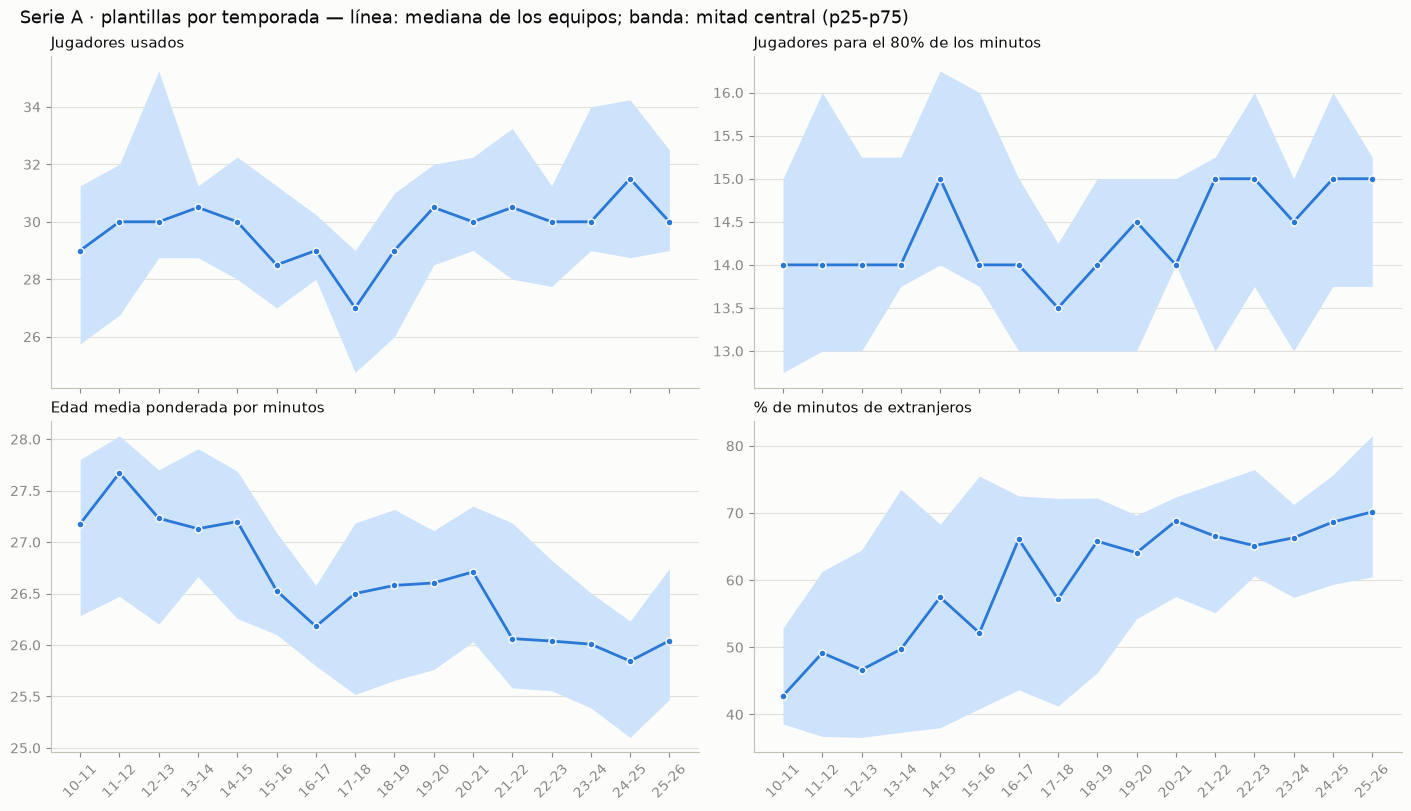

In [3]:
metricas = {"jugadores_usados": "Jugadores usados", "jugadores_80pct": "Jugadores para el 80% de los minutos",
            "edad_ponderada": "Edad media ponderada por minutos", "pct_min_extranjeros": "% de minutos de extranjeros"}
tendencia = liga.tendencia_liga(equipos, list(metricas))

fig, axs = plt.subplots(2, 2, figsize=(14, 8), sharex=True, constrained_layout=True)
for ax, (col, titulo) in zip(axs.ravel(), metricas.items()):
    ax.fill_between(TEMPORADAS, tendencia[("p25", col)], tendencia[("p75", col)], color=estilo.AZUL_CLARO, linewidth=0)
    ax.plot(TEMPORADAS, tendencia[("mediana", col)], color=estilo.AZUL, linewidth=2, marker="o", markersize=5,
            markeredgecolor=estilo.SUPERFICIE)
    ax.set_title(titulo)
    estilo.rejilla_y(ax)
for ax in axs[1]:
    estilo.etiquetas_temporada(ax, TEMPORADAS)
fig.suptitle(f"{LIGA} · plantillas por temporada — línea: mediana de los equipos; banda: mitad central (p25-p75)",
             x=0.01, ha="left", fontsize=13, color=estilo.TINTA)
fig.savefig(FIGURAS / f"{SLUG}_plantillas.png", dpi=150)
plt.show()

- **Rotación alta y estable**: 27-31.5 jugadores usados y 13.5-15 para el 80% de los minutos, de los valores más altos
  de las siete ligas junto con la Liga MX reciente.
- **Extranjeros al alza, y fuerte**: del 42.8% de los minutos en 2010-11 al **70.2%** en 2025-26, la segunda subida
  más grande después de la Ligue 1.
- **Rejuvenecimiento**: la edad de quien juega bajó de 27.7 años (2011-12, la más alta de todas las ligas) a 25.8-26.0
  en las últimas temporadas.

In [4]:
# Los extremos de todo el periodo: los equipos que más rotaron (más jugadores para cubrir el 80% de los minutos) y los
# que menos. Se muestra también el resultado (puntos por partido) para ver si rotar se asocia con ganar o perder.
columnas = ["season", "equipo", "jugadores_usados", "jugadores_80pct", "edad_ponderada", "pct_min_extranjeros", "ppg"]
print("Más rotación:")
display(equipos.nlargest(6, "jugadores_80pct")[columnas].round(1))
print("Menos rotación:")
display(equipos.nsmallest(6, "jugadores_80pct")[columnas].round(1))
rho = spearmanr(equipos["jugadores_80pct"], equipos["ppg"], nan_policy="omit").statistic
print(f"Rotación vs puntos por partido (Spearman, todos los equipo-temporadas): {rho:.2f}")

Más rotación:


,season,equipo,jugadores_usados,jugadores_80pct,edad_ponderada,pct_min_extranjeros,ppg
147,2017-2018,Benevento,41,22,25.5,38.5,0.6
233,2021-2022,Salernitana,42,21,27.4,67.3,0.8
50,2012-2013,Pescara,39,20,25.4,33.6,0.6
225,2021-2022,Genoa,40,20,26.5,48.9,0.7
272,2023-2024,Salernitana,39,20,26.8,70.1,0.4
78,2013-2014,Sassuolo,38,18,26.0,14.5,0.9


Menos rotación:


,season,equipo,jugadores_usados,jugadores_80pct,edad_ponderada,pct_min_extranjeros,ppg
114,2015-2016,Napoli,22,10,26.0,81.5,2.2
1,2010-2011,Udinese,24,11,25.2,68.1,1.7
10,2010-2011,Cagliari,22,11,25.8,12.2,1.2
18,2010-2011,Palermo,27,11,24.3,43.1,1.5
36,2011-2012,Juventus,25,11,27.4,25.9,2.2
155,2017-2018,Napoli,23,11,27.5,81.6,2.4


Rotación vs puntos por partido (Spearman, todos los equipo-temporadas): -0.41


La asociación entre rotar y perder es de las más fuertes: **−0.41**. Los casos extremos son elocuentes: Benevento
2017-18 necesitó 22 jugadores para el 80% de sus minutos (0.6 puntos por partido) y Salernitana 2021-22, 21 (0.8);
ambos descendieron. En el otro extremo, el Napoli 2015-16 usó 10 jugadores (2.2) y la Juventus 2011-12, 11 (2.2, la
temporada en que fue campeona sin perder un partido).

## 2. Porteros

Primero la liga completa: % de paradas (paradas / tiros a puerta recibidos), goles recibidos por partido y % de
partidos con portería a cero, sumando a todos los porteros antes de dividir (una tasa de la liga, no el promedio de
las tasas de cada portero). Después, cada portero en toda su carrera en la liga.

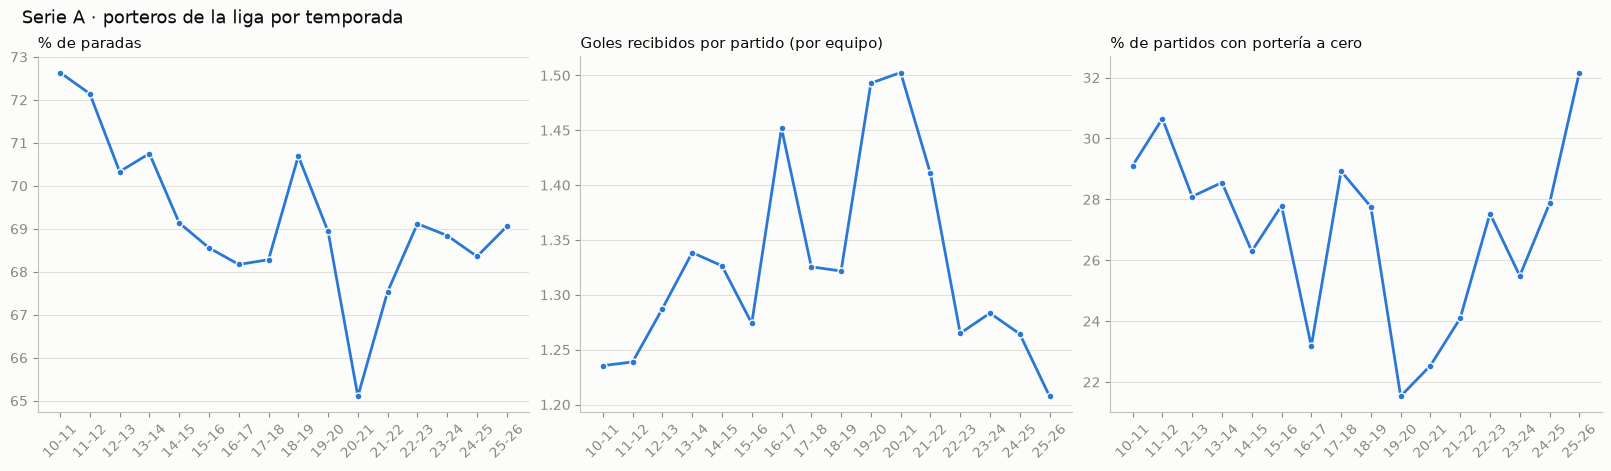

In [5]:
lp = liga.porteros_liga(jt, LIGA).reindex(TEMPORADAS)
paneles = {"pct_paradas": "% de paradas", "goles_recibidos_por_partido": "Goles recibidos por partido (por equipo)",
           "pct_porterias_cero": "% de partidos con portería a cero"}
fig, axs = plt.subplots(1, 3, figsize=(16, 4.6), sharex=True, constrained_layout=True)
for ax, (col, titulo) in zip(axs, paneles.items()):
    # Una temporada sin dato queda como hueco en la línea (no se une con la siguiente como si hubiera dato).
    ax.plot(TEMPORADAS, lp[col], color=estilo.AZUL, linewidth=2, marker="o", markersize=5,
            markeredgecolor=estilo.SUPERFICIE)
    faltan = [t for t in TEMPORADAS if pd.isna(lp.loc[t, col])]
    for t in faltan:
        ax.annotate("sin dato", (t, ax.get_ylim()[0]), xytext=(0, 4), textcoords="offset points", ha="center",
                    fontsize=8, color=estilo.TENUE)
    ax.set_title(titulo)
    estilo.rejilla_y(ax)
    estilo.etiquetas_temporada(ax, TEMPORADAS)
fig.suptitle(f"{LIGA} · porteros de la liga por temporada", x=0.01, ha="left", fontsize=13, color=estilo.TINTA)
fig.savefig(FIGURAS / f"{SLUG}_porteros_liga.png", dpi=150)
plt.show()

- **% de paradas**: baja de 72.6% (2010-11) a 69.1% (2025-26), con un mínimo marcado en 2020-21 (65.1%).
- **Goles recibidos por partido**: entre 1.21 y 1.50, con los valores más altos en 2019-21 y el más bajo en 2025-26.
- **Porterías a cero**: 2025-26 es la temporada con más (32.2%) y 2019-20 la que menos (21.5%).

In [6]:
# Carreras completas en la liga (mínimo 9,000 minutos ≈ 100 partidos): el % de paradas de toda la carrera pondera cada
# temporada por los tiros que recibió.
carreras = liga.carrera_porteros(jt, LIGA, min_minutos=9000)
columnas = ["portero", "equipos", "desde", "hasta", "partidos", "pct_paradas", "pct_porterias_cero", "goles_recibidos_90"]
display(carreras[columnas].head(12).round(2))

# ¿El % de paradas es del portero o de su defensa? Correlación entre una temporada y la siguiente (1,500+ minutos).
porteros_jt = jt[jt["gk_games"].notna()]
r_paradas, n_paradas, _ = liga.estabilidad(porteros_jt, "gk_save_pct", minutos="gk_minutes")
r_cero, n_cero, _ = liga.estabilidad(porteros_jt, "gk_clean_sheets_pct", minutos="gk_minutes")
print(f"Estabilidad año a año — % de paradas: r = {r_paradas:.2f} ({n_paradas} pares); "
      f"% porterías a cero: r = {r_cero:.2f} ({n_cero} pares)")

,portero,equipos,desde,hasta,partidos,pct_paradas,pct_porterias_cero,goles_recibidos_90
id_jugador,,,,,,,,
e40d028b,Gianluigi Buffon,Juventus,2010,2020,252.0,77.75,50.40,0.65
322421c2,Christian Abbiati,Milan,2010,2015,134.0,77.40,42.54,0.82
83228343,Morgan De Sanctis,Napoli / Roma,2010,2015,184.0,73.96,43.48,0.92
4e0c8d66,Michele Di Gregorio,Monza / Juventus,2022,2025,133.0,73.67,37.59,1.07
08f5afaa,Gianluigi Donnarumma,Milan,2015,2020,215.0,73.59,33.02,1.07
01b8a2b2,Wojciech Szczęsny,Roma / Juventus,2015,2023,272.0,73.55,37.13,0.93
8ec56e62,Marco Carnesecchi,Cremonese / Atalanta,2022,2025,125.0,73.46,30.40,1.17
fcb38f57,Mike Maignan,Milan,2021,2025,157.0,73.44,40.13,0.97
74419746,Samir Handanović,Udinese / Inter,2010,2022,453.0,72.90,37.97,1.03


Estabilidad año a año — % de paradas: r = 0.35 (198 pares); % porterías a cero: r = 0.45 (198 pares)


**Gianluigi Buffon** domina las tres métricas entre los 45 porteros con 100+ partidos, algo que en las otras ligas no
pasa: 77.8% de paradas, 50.4% de porterías a cero y 0.65 goles recibidos por 90 en 252 partidos con la Juventus. Le
siguen Abbiati y De Sanctis; entre los actuales, Maignan (73.4%) y Carnesecchi (73.5%).

Estabilidad año a año: % de paradas 0.35 y porterías a cero **0.45**, la más alta de las siete ligas: en la Serie A,
quién deja la portería en cero se repite mucho de un año a otro.

In [7]:
# La última temporada, porteros con 900+ minutos. Y un control de calidad: goles recibidos según la tabla de porteros
# vs. goles recibidos por su equipo con él en cancha (onGA). Deberían coincidir; donde no, FBref se contradice.
ultima = jt[(jt["temporada_inicio"] == TEMPORADAS[-1]) & (jt["gk_minutes"] >= 900)]
display(ultima.sort_values("gk_save_pct", ascending=False)[
    ["player", "equipo_principal", "gk_games", "gk_save_pct", "gk_clean_sheets", "gk_goals_against",
     "on_goals_against"]].round(1))

por_temporada = liga.desacuerdo_goles_porteros(porteros_jt)
print(f"Porteros-temporada con ambos datos: {por_temporada['porteros'].sum()}; no coinciden: "
      f"{por_temporada['no_coinciden'].sum()}. Por temporada:")
display(por_temporada.set_index("temporada_inicio").T)
con_ambos = porteros_jt[porteros_jt["on_goals_against"].notna()]
difiere = con_ambos[con_ambos["gk_goals_against"] != con_ambos["on_goals_against"]]
print("Los de mayor diferencia:")
display(difiere.assign(diferencia=difiere["on_goals_against"] - difiere["gk_goals_against"])
        .reindex(columns=["player", "season", "equipo_principal", "gk_games", "gk_goals_against", "on_goals_against",
                          "diferencia"])
        .sort_values("diferencia", key=abs, ascending=False).head(5))

,player,equipo_principal,gk_games,gk_save_pct,gk_clean_sheets,gk_goals_against,on_goals_against
59261,Mile Svilar,Roma,38.0,77.5,18.0,31.0,31.0
59206,Marco Carnesecchi,Atalanta,37.0,75.7,13.0,35.0,35.0
59259,Mike Maignan,Milan,37.0,75.2,14.0,35.0,35.0
59100,Ivan Provedel,Lazio,27.0,75.0,12.0,27.0,27.0
59114,Jean Butez,Como,38.0,74.1,19.0,29.0,29.0
58930,Arijanet Muric,Sassuolo,32.0,73.3,6.0,43.0,43.0
59019,Emil Audero,Cremonese,34.0,71.1,11.0,50.0,50.0
58991,David de Gea,Fiorentina,37.0,70.4,10.0,49.0,49.0
59441,Zion Suzuki,Parma,20.0,69.9,5.0,28.0,28.0
59009,Edoardo Corvi,Parma,17.0,69.8,7.0,18.0,18.0


Porteros-temporada con ambos datos: 561; no coinciden: 22. Por temporada:


temporada_inicio,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
no_coinciden,2,2,2,1,2,3,3,3,0,1,0,3
porteros,45,47,44,40,45,48,51,49,48,51,47,46


Los de mayor diferencia:


,player,season,equipo_principal,gk_games,gk_goals_against,on_goals_against,diferencia
59194,Maduka Okoye,2025-2026,Udinese,30.0,37.0,32.0,-5.0
54767,Vid Belec,2017-2018,Benevento,15.0,37.0,32.0,-5.0
59451,Łukasz Skorupski,2025-2026,Bologna,19.0,18.0,15.0,-3.0
56464,Vanja Milinković-Savić,2020-2021,Torino,5.0,6.0,9.0,3.0
55494,Etrit Berisha,2019-2020,SPAL,26.0,41.0,44.0,3.0


En 2025-26 encabezan **Mile Svilar** (Roma, 77.5% y 18 porterías a cero en 38 partidos), Marco Carnesecchi (Atalanta,
75.7%) y Mike Maignan (Milan, 75.2%); los últimos con 900+ minutos son Alex Meret (Napoli, 63.6%) y Lorenzo Montipò
(Hellas Verona, 61.3%).

**Calidad de datos**: de 0 a 3 porteros por temporada con distinto número de goles recibidos entre las dos tablas de
FBref; como la Premier, es de las ligas más limpias.

## 3. Impacto en cancha

FBref publica, desde 2014-15, dos medidas de "qué pasa cuando el jugador está en la cancha":

- **on-off** (`plus_minus_wowy`): goles netos de su equipo por 90 minutos con él en cancha, menos sin él;
- **puntos por partido con él** (`points_per_game`). Aquí se compara con los puntos por partido de su equipo en toda
  la temporada: `ppg_extra` = puntos con él − puntos del equipo (solo jugadores con un solo equipo esa temporada, para
  que la comparación sea limpia).

Son tentadoras como medida de "impacto", pero están muy expuestas a cosas ajenas al jugador: con quién comparte
cancha, contra quién jugó, si solo entra cuando el partido está roto. Antes de usarlas hay que probar si miden algo
**del jugador**: si fuera así, quien sale alto una temporada tendería a salir alto la siguiente. Como referencia de lo
que se ve cuando una medida sí es del jugador, se agrega una métrica individual: goles sin penal por 90 de los
delanteros.

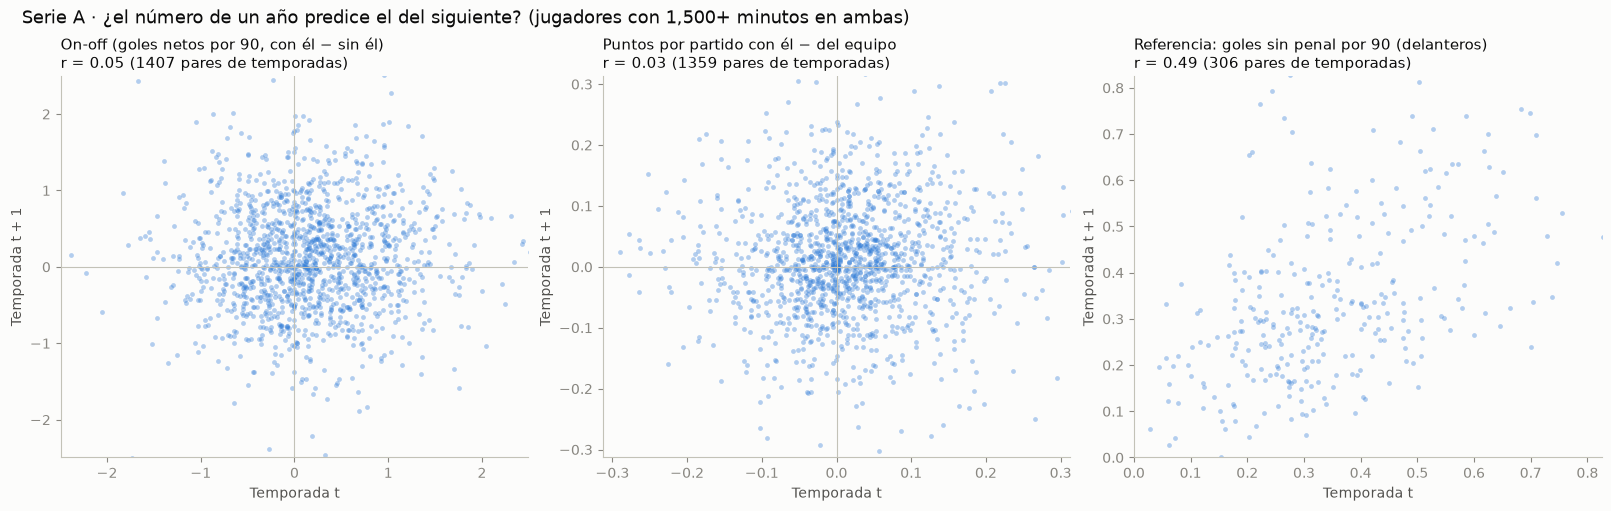

,r,pares
"On-off (goles netos por 90, con él − sin él)",0.05,1407.0
Puntos por partido con él − del equipo,0.03,1359.0
Referencia: goles sin penal por 90 (delanteros),0.49,306.0


In [8]:
# ppg_extra = puntos por partido con él − del equipo; solo jugadores con un equipo en la temporada (ver docstring).
jt = liga.agregar_ppg_extra(jt, equipos)

pruebas = {
    "plus_minus_wowy": ("On-off (goles netos por 90, con él − sin él)", jt),
    "ppg_extra": ("Puntos por partido con él − del equipo", jt),
    "goals_pens_per90": ("Referencia: goles sin penal por 90 (delanteros)", jt[jt["pos_principal"] == "FW"]),
}
fig, axs = plt.subplots(1, 3, figsize=(16, 5), constrained_layout=True)
resumen_estabilidad = {}
for ax, (col, (titulo, datos)) in zip(axs, pruebas.items()):
    r, n, pares = liga.estabilidad(datos, col, min_minutos=1500)
    resumen_estabilidad[titulo] = {"r": round(r, 2), "pares": n}
    ax.scatter(pares[col], pares[f"{col}_siguiente"], s=12, color=estilo.AZUL, alpha=0.35, linewidths=0)
    lim = np.nanpercentile(np.abs(pares[[col, f"{col}_siguiente"]].to_numpy()), 99)
    if col == "goals_pens_per90":
        ax.set_xlim(0, lim); ax.set_ylim(0, lim)
    else:
        ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
        ax.axhline(0, color=estilo.EJE, linewidth=0.8); ax.axvline(0, color=estilo.EJE, linewidth=0.8)
    ax.set_title(f"{titulo}\nr = {r:.2f} ({n} pares de temporadas)")
    ax.set_xlabel("Temporada t"); ax.set_ylabel("Temporada t + 1")
fig.suptitle(f"{LIGA} · ¿el número de un año predice el del siguiente? (jugadores con 1,500+ minutos en ambas)",
             x=0.01, ha="left", fontsize=13, color=estilo.TINTA)
fig.savefig(FIGURAS / f"{SLUG}_impacto_estabilidad.png", dpi=150)
plt.show()
pd.DataFrame(resumen_estabilidad).T

| Medida | Correlación año a año |
|---|---|
| On-off (goles netos con él − sin él) | **0.05** (1,407 pares) |
| Puntos por partido con él − del equipo | **0.03** (1,359 pares) |
| Referencia: goles sin penal por 90 (delanteros) | **0.49** (306 pares) |

Mismo patrón que en las demás ligas. Aquí incluso la referencia individual es más baja (0.49): en la Serie A los
goles por 90 de un delantero se repiten menos de un año a otro que en La Liga (0.69) o la Premier (0.62).

## 4. Fantasy y dependencia

Dos preguntas sobre cómo se reparte la producción dentro de cada equipo:

1. **Dependencia del goleador**: qué parte de los goles del equipo hizo su máximo goleador. ¿Depender de un solo
   jugador se asocia con sumar más o menos puntos?
2. **El mejor jugador fantasy de cada equipo** en la última temporada y qué parte de los puntos fantasy del equipo
   hizo (con el esquema ofensivo del notebook 17; los puntos de un jugador traspasado cuentan para su equipo
   principal).

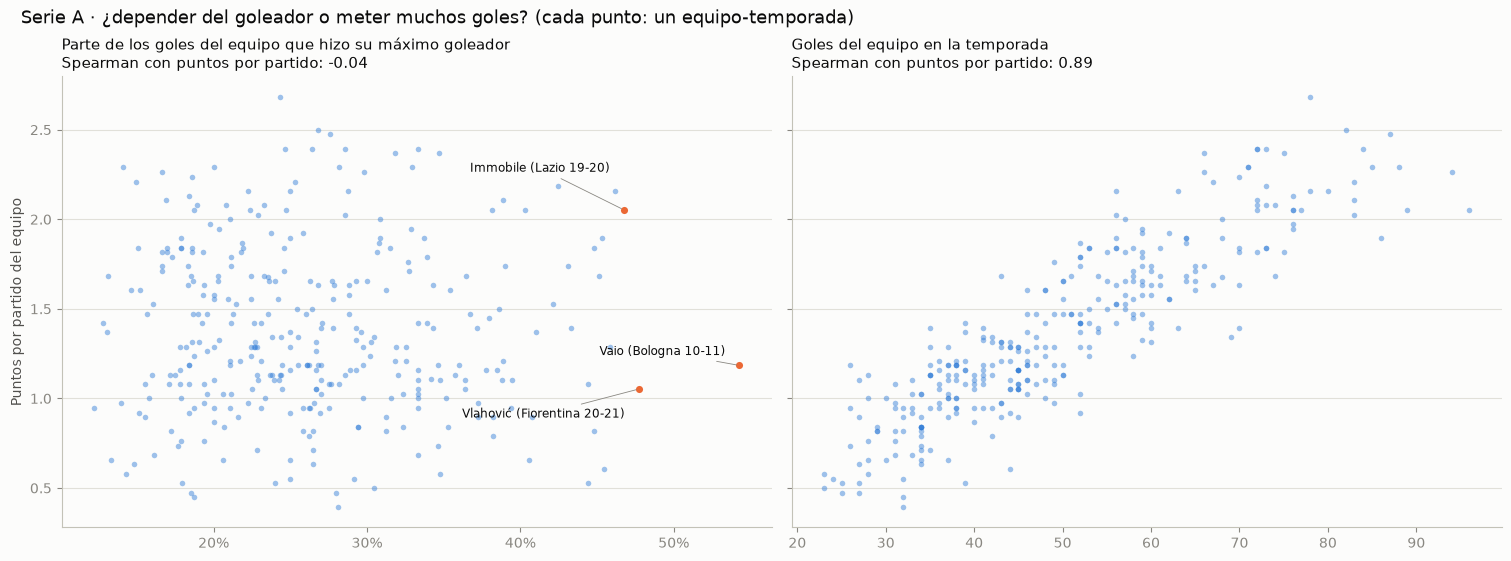

,season,equipo,goleador,goles_goleador,goles,dependencia_goleador,ppg
2,2010-2011,Bologna,Marco Di Vaio,19.0,35.0,0.54,1.18
205,2020-2021,Fiorentina,Dušan Vlahović,21.0,44.0,0.48,1.05
188,2019-2020,Lazio,Ciro Immobile,36.0,77.0,0.47,2.05
114,2015-2016,Napoli,Gonzalo Higuaín,36.0,78.0,0.46,2.16
81,2014-2015,Hellas Verona,Luca Toni,22.0,48.0,0.46,1.29
204,2020-2021,Crotone,Simeon Nwankwo,20.0,44.0,0.45,0.61
156,2017-2018,Inter,Mauro Icardi,29.0,64.0,0.45,1.89
20,2011-2012,Udinese,Antonio Di Natale,23.0,51.0,0.45,1.68


Mediana de la dependencia por temporada: {'2010-2011': 0.24, '2011-2012': 0.3, '2012-2013': 0.26, '2013-2014': 0.27, '2014-2015': 0.26, '2015-2016': 0.25, '2016-2017': 0.29, '2017-2018': 0.27, '2018-2019': 0.26, '2019-2020': 0.23, '2020-2021': 0.24, '2021-2022': 0.27, '2022-2023': 0.23, '2023-2024': 0.22, '2024-2025': 0.23, '2025-2026': 0.21}


In [9]:
fig, axs = plt.subplots(1, 2, figsize=(15, 5.5), sharey=True, constrained_layout=True)
rho_dep = spearmanr(equipos["dependencia_goleador"], equipos["ppg"], nan_policy="omit").statistic
rho_gol = spearmanr(equipos["goles"], equipos["ppg"], nan_policy="omit").statistic
for ax, (col, titulo, rho, fmt) in zip(axs, [
        ("dependencia_goleador", "Parte de los goles del equipo que hizo su máximo goleador", rho_dep, "{:.0%}"),
        ("goles", "Goles del equipo en la temporada", rho_gol, "{:.0f}")]):
    ax.scatter(equipos[col], equipos["ppg"], s=16, color=estilo.AZUL, alpha=0.45, linewidths=0)
    ax.set_title(f"{titulo}\nSpearman con puntos por partido: {rho:.2f}")
    estilo.rejilla_y(ax)
    if col == "dependencia_goleador":
        ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
        # Se resaltan los 3 equipos más dependientes. Las etiquetas se escalonan en vertical porque dos de ellos tienen
        # exactamente 1.00 punto por partido y quedarían encimadas.
        for k, (_, e) in enumerate(equipos.nlargest(3, col).iterrows()):
            ax.scatter(e[col], e["ppg"], s=44, color=estilo.NARANJA, edgecolors=estilo.SUPERFICIE, linewidths=1.5,
                       zorder=3)
            nombre = e["goleador"] if len(e["goleador"]) <= 12 else e["goleador"].split()[-1]
            ax.annotate(f"{nombre} ({e['equipo']} {e['season'][2:4]}-{e['season'][7:]})", (e[col], e["ppg"]),
                        xytext=(-10, [10, -18, 30][k]), textcoords="offset points", ha="right", va="center",
                        fontsize=8.5, color=estilo.TINTA,
                        arrowprops=dict(arrowstyle="-", color=estilo.TENUE, linewidth=0.6))
axs[0].set_ylabel("Puntos por partido del equipo")
fig.suptitle(f"{LIGA} · ¿depender del goleador o meter muchos goles? (cada punto: un equipo-temporada)",
             x=0.01, ha="left", fontsize=13, color=estilo.TINTA)
fig.savefig(FIGURAS / f"{SLUG}_dependencia_goleador.png", dpi=150)
plt.show()

display(equipos.nlargest(8, "dependencia_goleador")[
    ["season", "equipo", "goleador", "goles_goleador", "goles", "dependencia_goleador", "ppg"]].round(2))
print("Mediana de la dependencia por temporada:",
      equipos.groupby("season")["dependencia_goleador"].median().round(2).to_dict())

- **La dependencia del goleador es lo más parecido a "nada" de todas las ligas** (−0.04, ligeramente negativa), y los
  goles del equipo son lo que más se asocia con los puntos en todo el panel: **0.89**.
- Los más dependientes: Marco Di Vaio hizo el 54% de los goles del Bologna 2010-11 y Dušan Vlahović el 48% de la
  Fiorentina 2020-21. Con buenos resultados: **Ciro Immobile** (36 goles, 47% del Lazio 2019-20, 2.05 puntos por
  partido) y **Gonzalo Higuaín** (36 goles, 46% del Napoli 2015-16, 2.16).
- La dependencia mediana bajó de 0.24-0.30 a 0.21-0.23 en las últimas temporadas.

In [10]:
# Mejor jugador fantasy de cada equipo en la última temporada y su parte de los puntos del equipo.
mejores = liga.mejor_fantasy_por_equipo(jt, TEMPORADAS[-1])
mejores[["equipo_principal", "player", "pos_principal", "goals", "assists", "pts_total", "pts_equipo",
         "parte_del_equipo", "pct_pts_jornada"]].round(2)

,equipo_principal,player,pos_principal,goals,assists,pts_total,pts_equipo,parte_del_equipo,pct_pts_jornada
58932,Sassuolo,Armand Lauriente,FW,7.0,9.0,122.0,1177.0,0.10,95.97
59145,Juventus,Kenan Yıldız,MF,10.0,6.0,133.0,1341.0,0.10,98.71
59283,Como,Nicolás Paz,MF,12.0,6.0,137.0,1386.0,0.10,99.35
59338,Napoli,Rasmus Højlund,FW,12.0,5.0,127.0,1312.0,0.10,98.39
59297,Torino,Nikola Vlašić,MF,8.0,3.0,115.0,1203.0,0.10,97.42
59224,Parma,Mateo Pellegrino,FW,9.0,1.0,105.0,1099.0,0.10,87.90
59033,Cremonese,Federico Bonazzoli,FW,10.0,1.0,105.0,1105.0,0.10,87.90
59035,Inter,Federico Dimarco,MF,7.0,16.0,145.0,1538.0,0.09,100.00
59351,Fiorentina,Rolando Mandragora,MF,7.0,3.0,101.0,1137.0,0.09,94.19
59389,Pisa,Stefano Moreo,FW,7.0,1.0,95.0,1101.0,0.09,79.03


La Serie A es la liga con los puntos fantasy **más repartidos**: el mejor de cada equipo aporta entre el 6% y el 10%
de los puntos de su equipo (en la Bundesliga llega al 13% y en la Liga MX al 15%). El puntaje más alto de 2025-26 es
de **Federico Dimarco** (Inter, 145 puntos con 16 asistencias, percentil 100), seguido de Nicolás Paz (Como) y Kenan
Yıldız (Juventus).

## 5. Conclusiones y cómo ampliar a otra liga

**Serie A, 2010-11 a 2025-26:**

1. **Plantillas**: rotación alta y estable (13.5-15 jugadores para el 80% de los minutos), extranjeros del 42.8% al
   70.2% de los minutos y plantillas claramente más jóvenes que al inicio del periodo. Rotar vs. puntos: −0.41, de
   las asociaciones más fuertes.
2. **Porteros**: Buffon es el mejor del periodo en las tres métricas (77.8% de paradas, 50.4% de porterías a cero,
   0.65 goles recibidos por 90). Las porterías a cero son lo más estable año a año de las siete ligas (0.45).
3. **Impacto en cancha**: on-off 0.05 y puntos con él 0.03; hasta la referencia individual es baja (0.49).
4. **Dependencia**: −0.04 con los puntos (la más plana) y goles del equipo 0.89 (la más fuerte del panel). Los
   puntos fantasy están más repartidos que en cualquier otra liga publicada.